<a href="https://colab.research.google.com/github/ajayrfhp/super-octo-puzzles/blob/main/double_to_win.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Double to win

**Problem**
- You are given C units of money to play the below game.
In each round, you multiply current amount by 2 or lose half of current money with equal probability. What is the expected money that you will have after n rounds.

**Solution**
- Expected value of a random variable X over a distribution P(x) is defined as

 $E(X) = ∑xP(x)$

 - In this case, there are only 2 outcomes each with the same probability. Expected value after one round can be estimated as

  $E(C_1) = 0.5 * 0.5 * C + 0.5 * 2 * C = 1.25C$

- The recurrence can be written as follows,

  $E(C_n) = 1.25*E(C_{n-1})$

  $E(C_n) = 1.25^n*C$

**Simulation**  

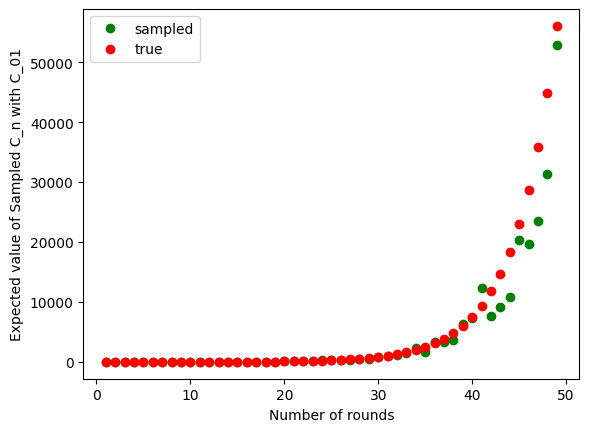

In [35]:
import numpy as np
from matplotlib import pyplot as plt

def sample_run(c, n):
  for i in range(n):
    if np.random.rand() <= 0.5:
      c *= 2
    else:
      c /= 2
  return c

def get_expected_value(c, n, num_sample_runs):
  expected_value = 0
  for i in range(num_sample_runs):
    expected_value += sample_run(c, n)
  return expected_value / num_sample_runs

def graph_expected_value(c=1, num_sample_runs=1):
  x = []
  y = []
  t_y = []
  for n in range(1, 50):
    x.append(n)
    y.append(get_expected_value(c, n, num_sample_runs))
    t_y.append(1.25**n * c)

  plt.plot(x, y, 'o', color='green', label='sampled')
  plt.plot(x, t_y, 'o', color='red', label='true')
  plt.legend()
  plt.xlabel('Number of rounds')
  plt.ylabel(f'Expected value of Sampled C_n with C_0{c}')
  plt.show()

  return x, y, t_y

x, y, t_y = graph_expected_value(c=1, num_sample_runs=100000)


## Moral
- Keep doubling down till you win in gambling.